In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/kyanyoga/sample-sales-data/sales_data_sample.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Style
sns.set(style='whitegrid')

## 1. LOAD DATASET

In [3]:
df = pd.read_csv('/kaggle/input/datasets/kyanyoga/sample-sales-data/sales_data_sample.csv', encoding='latin1')

In [4]:
# Display basic info
df.head()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,...,897 Long Airport Avenue,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,5/7/2003 0:00,Shipped,2,5,2003,...,59 rue de l'Abbaye,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,7/1/2003 0:00,Shipped,3,7,2003,...,27 rue du Colonel Pierre Avia,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,8/25/2003 0:00,Shipped,3,8,2003,...,78934 Hillside Dr.,NaN,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium
4,10159,49,100.00,14,5205.27,10/10/2003 0:00,Shipped,4,10,2003,...,7734 Strong St.,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2823 entries, 0 to 2822
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ORDERNUMBER       2823 non-null   int64  
 1   QUANTITYORDERED   2823 non-null   int64  
 2   PRICEEACH         2823 non-null   float64
 3   ORDERLINENUMBER   2823 non-null   int64  
 4   SALES             2823 non-null   float64
 5   ORDERDATE         2823 non-null   object 
 6   STATUS            2823 non-null   object 
 7   QTR_ID            2823 non-null   int64  
 8   MONTH_ID          2823 non-null   int64  
 9   YEAR_ID           2823 non-null   int64  
 10  PRODUCTLINE       2823 non-null   object 
 11  MSRP              2823 non-null   int64  
 12  PRODUCTCODE       2823 non-null   object 
 13  CUSTOMERNAME      2823 non-null   object 
 14  PHONE             2823 non-null   object 
 15  ADDRESSLINE1      2823 non-null   object 
 16  ADDRESSLINE2      302 non-null    object 


In [6]:
df.describe()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,QTR_ID,MONTH_ID,YEAR_ID,MSRP
count,2823.000000,2823.000000,2823.000000,2823.000000,2823.000000,2823.000000,2823.000000,2823.00000,2823.000000
mean,10258.725115,35.092809,83.658544,6.466171,3553.889072,2.717676,7.092455,2003.81509,100.715551
std,92.085478,9.741443,20.174277,4.225841,1841.865106,1.203878,3.656633,0.69967,40.187912
min,10100.000000,6.000000,26.880000,1.000000,482.130000,1.000000,1.000000,2003.00000,33.000000
25%,10180.000000,27.000000,68.860000,3.000000,2203.430000,2.000000,4.000000,2003.00000,68.000000
50%,10262.000000,35.000000,95.700000,6.000000,3184.800000,3.000000,8.000000,2004.00000,99.000000
75%,10333.500000,43.000000,100.000000,9.000000,4508.000000,4.000000,11.000000,2004.00000,124.000000
max,10425.000000,97.000000,100.000000,18.000000,14082.800000,4.000000,12.000000,2005.00000,214.000000


## 2. DATA CLEANING

In [7]:
# Drop irrelevant columns
drop_cols = [
    'ADDRESSLINE1','ADDRESSLINE2','CONTACTFIRSTNAME',
    'CONTACTLASTNAME','POSTALCODE','ORDERNUMBER'
]
df.drop(columns=drop_cols, inplace=True)

In [8]:
# Handle missing values
df['STATE'] = df['STATE'].fillna('Unknown')
df['TERRITORY'] = df['TERRITORY'].fillna('Unknown')

# Convert date
df['ORDERDATE'] = pd.to_datetime(df['ORDERDATE'])

## 3. FEATURE ENGINEERING

In [9]:
df['YEAR'] = df['ORDERDATE'].dt.year
df['MONTH'] = df['ORDERDATE'].dt.month

df.drop('ORDERDATE', axis=1, inplace=True)

## 4. EXPLORATORY DATA ANALYSIS (EDA)

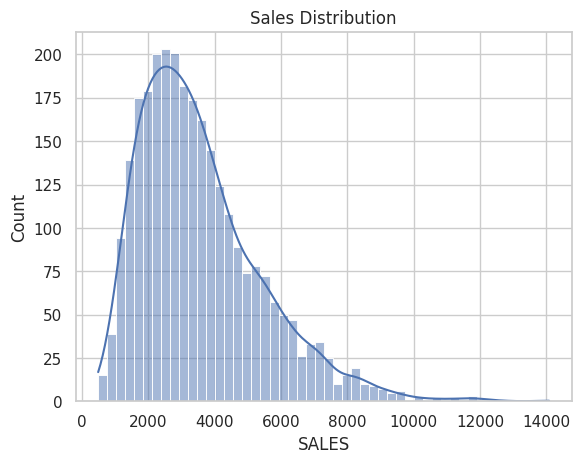

In [10]:
# Sales distribution
plt.figure()
sns.histplot(df['SALES'], bins=50, kde=True)
plt.title("Sales Distribution")
plt.show()

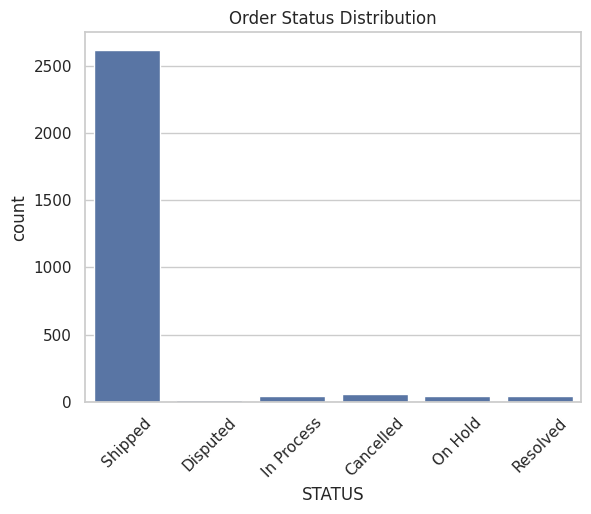

In [11]:
# Status distribution
plt.figure()
sns.countplot(x='STATUS', data=df)
plt.title("Order Status Distribution")
plt.xticks(rotation=45)
plt.show()

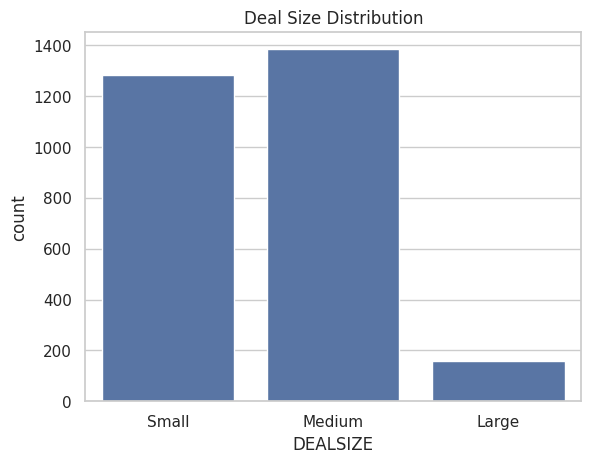

In [12]:
# Deal Size count
plt.figure()
sns.countplot(x='DEALSIZE', data=df)
plt.title("Deal Size Distribution")
plt.show()

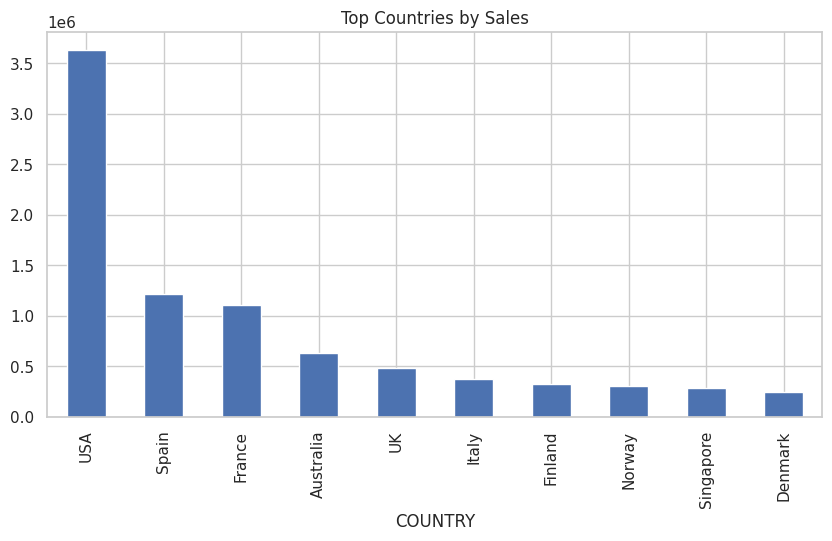

In [13]:
# Sales by Country
plt.figure(figsize=(10,5))
df.groupby('COUNTRY')['SALES'].sum().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top Countries by Sales")
plt.show()

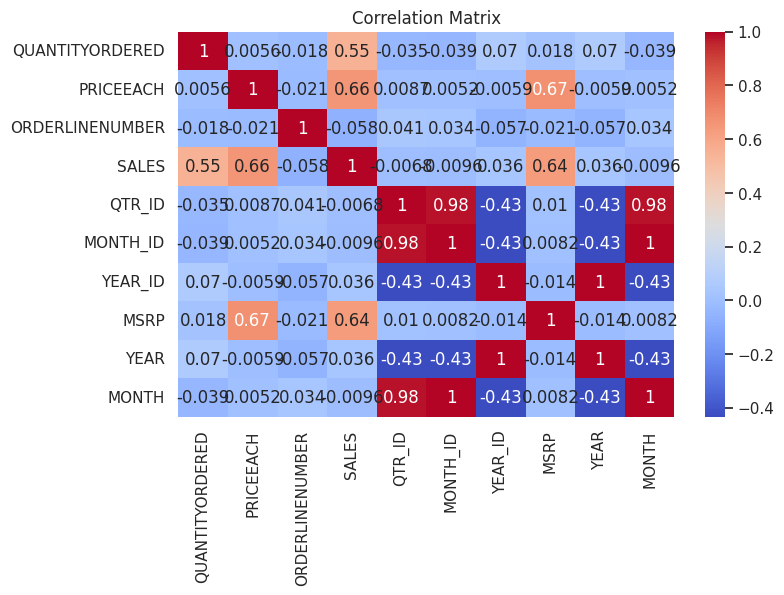

In [14]:
# Correlation heatmap
plt.figure(figsize=(8,5))
numeric_df = df.select_dtypes(include=np.number)
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

## 5. ENCODING CATEGORICAL DATA

In [15]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [16]:
X = df.drop('STATUS', axis=1)
y = df['STATUS']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## 6. RANDOM FOREST MODEL

In [17]:
rf = RandomForestClassifier(n_estimators=150, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=150, random_state=42)

In [18]:
y_pred = rf.predict(X_test)

## 7. EVALUATION

In [19]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.984070796460177

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        17
           1       0.80      1.00      0.89         4
           2       1.00      0.69      0.82        13
           3       0.75      0.75      0.75         8
           4       1.00      0.90      0.95        10
           5       0.99      1.00      0.99       513

    accuracy                           0.98       565
   macro avg       0.92      0.89      0.90       565
weighted avg       0.98      0.98      0.98       565



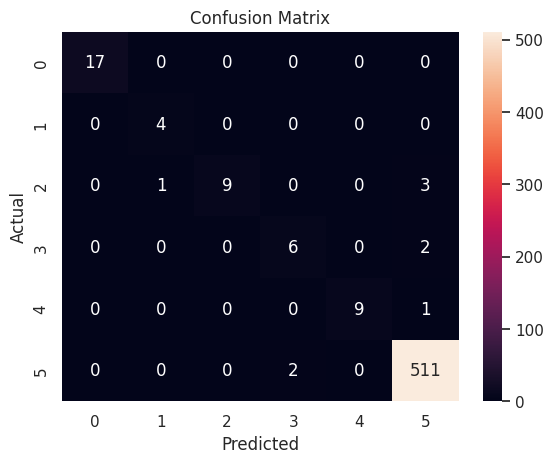

In [20]:
# Confusion Matrix
plt.figure()
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## 8. FEATURE IMPORTANCE

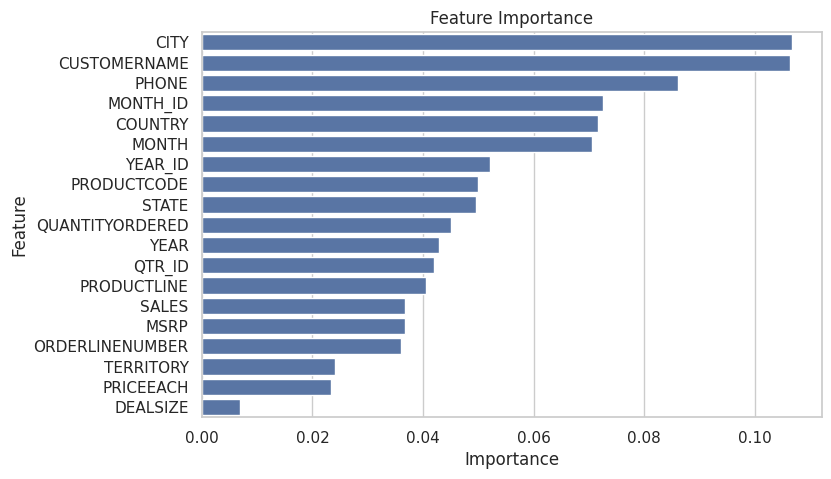

            Feature  Importance
12             CITY    0.106821
10     CUSTOMERNAME    0.106324
11            PHONE    0.086068
5          MONTH_ID    0.072556
14          COUNTRY    0.071628
18            MONTH    0.070572
6           YEAR_ID    0.052071
9       PRODUCTCODE    0.050013
13            STATE    0.049579
0   QUANTITYORDERED    0.045024


In [21]:
feat_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x='Importance', y='Feature', data=feat_imp)
plt.title("Feature Importance")
plt.show()

print(feat_imp.head(10))

## CONCLUSION

The Random Forest model achieved very high accuracy (98.4%), indicating strong performance in classifying order status. The model effectively handled both numerical and categorical features, with key factors such as CITY, CUSTOMERNAME, PHONE, and time-related features contributing most to predictions.

The classification report shows excellent performance for major classes, though minor classes have slightly lower recall due to imbalance. Overall, the model is robust, reliable, and suitable for business intelligence applications, helping organizations predict order outcomes and improve decision-making.